
# Semana 7 — Implementación de un Algoritmo Genético Simple
# Sala 2
# Integrantes:
Jhon Tinjaca(jetinjaca@ucundinamarca.edu.co),
Edgar Bustos(edavidbustos@ucundinamarca.edu.co),
Julián Silva(jdsilva@ucundinamarca.edu.co).

**CADI:** Machine Learning y Algoritmos Genéticos  
**Universidad de Cundinamarca**

## Propósito de la práctica
Implementar y experimentar con un **Algoritmo Genético Simple** usando Python y la librería `geneticalgorithm2`.

Durante aproximadamente **40 minutos**, cada grupo deberá:

1. Ejecutar una configuración inicial o **línea base**.
2. Realizar **mínimo tres experimentos** modificando parámetros del algoritmo.
3. Comparar los resultados.
4. Elegir su mejor configuración.
5. Preparar una conclusión breve para socializar.

> **Importante:** todos los grupos trabajan el mismo problema. Cada grupo decide qué parámetros modificar y cómo justificar sus decisiones.



## Ruta de trabajo sugerida

- **0–10 min:** comprender el problema y ejecutar la línea base.
- **10–25 min:** realizar al menos tres experimentos.
- **25–35 min:** construir y ejecutar una mejor configuración.
- **35–40 min:** preparar la conclusión del grupo.

### Pregunta central
**¿Cómo cambian la calidad de la solución y el tiempo de ejecución cuando modificamos los parámetros del Algoritmo Genético?**


## 1. Instalar la librería

In [ ]:
import sys
!{sys.executable} -m pip -q install geneticalgorithm2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.0 MB/s eta 0:00:00


## 2. Importar librerías

In [ ]:

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from geneticalgorithm2 import GeneticAlgorithm2 as ga

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.



## 3. Problema de optimización

Queremos encontrar los valores de **x** y **y** que minimicen la función:

\[
f(x,y) = (x-3)^2 + (y+2)^2
\]

El mínimo teórico se encuentra en:

\[
x=3,\quad y=-2,\quad f(x,y)=0
\]

El Algoritmo Genético **no recibe directamente esa respuesta**. Debe explorar el espacio de búsqueda y aproximarse a ella.

Para esta práctica:

- `x ∈ [-10, 10]`
- `y ∈ [-10, 10]`
- Una solución candidata o **individuo** será `[x, y]`.
- La función objetivo corresponde al valor que queremos **minimizar**.


In [ ]:

def funcion_objetivo(X):
    x, y = X
    return (x - 3)**2 + (y + 2)**2

limites = [[-10, 10], [-10, 10]]

print("Ejemplo: f(0, 0) =", funcion_objetivo([0, 0]))
print("Óptimo teórico: f(3, -2) =", funcion_objetivo([3, -2]))


Ejemplo: f(0, 0) = 13
Óptimo teórico: f(3, -2) = 0



## 4. ¿Qué parámetros vamos a experimentar?

En esta práctica modificaremos principalmente:

- **Tamaño de población (`population_size`)**: cantidad de individuos por generación.
- **Número de generaciones (`max_num_iteration`)**: cuántas veces evoluciona la población.
- **Probabilidad de mutación (`mutation_probability`)**: frecuencia con que aparecen cambios aleatorios.
- **Probabilidad de cruce (`crossover_probability`)**: frecuencia con que dos progenitores recombinan información.

Mantendremos constantes otros parámetros para facilitar la comparación.


## 5. Función auxiliar para ejecutar y registrar experimentos

In [ ]:
resultados = []

def ejecutar_experimento(
    nombre,
    poblacion=40,
    generaciones=60,
    mutacion=0.10,
    cruce=0.70,
    seed=42,
    mostrar_curva=True
):
    """
    Ejecuta un experimento de optimización utilizando un Algoritmo Genético Simple.

    Parámetros:
    ----------
    nombre : str
        Identificador único del experimento para el registro de resultados.
    poblacion : int
        Tamaño de la población (número de individuos / soluciones candidatas por generación).
    generaciones : int
        Número máximo de iteraciones o ciclos evolutivos del algoritmo.
    mutacion : float
        Probabilidad de mutación. Controla el grado de exploración aleatoria global.
    cruce : float
        Probabilidad de recombinación (crossover). Controla la explotación de buenas soluciones.
    seed : int
        Semilla pseudoaleatoria para garantizar la reproducibilidad científica de las pruebas.
    mostrar_curva : bool
        Indica si se debe renderizar el gráfico de la curva de convergencia al finalizar.

    Retorna:
    ------
    modelo : GeneticAlgorithm2
        Instancia del modelo del algoritmo genético configurado y ejecutado.
    resultado : output_dict
        Objeto que contiene la mejor variable encontrada y su correspondiente fitness.
    """

    # 1. Definición paramétrica del algoritmo evolutivo
    parametros = {
        'max_num_iteration': generaciones, # Criterio de parada temporal por generaciones
        'population_size': poblacion,      # Espacio muestral inicial y continuo
        'mutation_probability': mutacion,  # Tasa de alteración del genotipo
        'elit_ratio': 0.02,                # Conserva el 2% de los mejores individuos sin alterar (Elitismo)
        'parents_portion': 0.30,           # Proporción de la población seleccionada como progenitores
        'crossover_probability': cruce,    # Tasa de cruce
        'crossover_type': 'uniform',       # Recombinación uniforme bit a bit para mayor diversidad
        'mutation_type': 'uniform_by_center', # Mutación uniforme centrada en la media del gen
        'selection_type': 'roulette',      # Selección por ruleta (proporcional al fitness)
        'max_iteration_without_improv': None # Evita parada temprana para asegurar ciclos completos
    }

    # 2. Inicialización del framework geneticalgorithm2
    modelo = ga(
        dimension=2,                      # Optimización bidimensional (x, y)
        variable_type='real',             # Representación de genes de tipo flotante / continuo
        variable_boundaries=limites,      # Dominio de búsqueda definido: [-10, 10]
        algorithm_parameters=parametros
    )

    # 3. Medición precisa de tiempo computacional y ejecución del ciclo evolutivo
    inicio = time.perf_counter()

    resultado = modelo.run(
        function=funcion_objetivo,        # Función matemática f(x, y) a minimizar
        no_plot=True,                     # Desactiva el plot por defecto de la librería
        progress_bar_stream=None,         # Desactiva flujos redundantes de interfaz
        disable_printing=True,            # Mantiene el entorno limpio evitando logs por iteración
        seed=seed                         # Establece la semilla para estabilidad estocástica
    )

    tiempo = time.perf_counter() - inicio # Tiempo de CPU neto empleado en la búsqueda

    # 4. Extracción de métricas de la solución óptima
    mejor_variable = np.array(resultado.variable, dtype=float)
    mejor_score = float(resultado.score)

    # 5. Consolidación y almacenamiento de los datos experimentales
    fila = {
        "Experimento": nombre,
        "Población": poblacion,
        "Generaciones": generaciones,
        "Mutación": mutacion,
        "Cruce": cruce,
        "x": mejor_variable[0],
        "y": mejor_variable[1],
        "Mejor fitness": mejor_score,
        "Tiempo (s)": tiempo
    }
    resultados.append(fila)

    # 6. Reporte estructurado en consola
    print(f"--- {nombre} ---")
    print(f"Mejor solución: x={mejor_variable[0]:.6f}, y={mejor_variable[1]:.6f}")
    print(f"Mejor fitness: {mejor_score:.8f}")
    print(f"Tiempo de Cómputo: {tiempo:.4f} s")

    # 7. Graficación de la trayectoria de optimización
    if mostrar_curva:
        plt.figure(figsize=(7, 4))
        plt.plot(modelo.report, label="Historial de Fitness")
        plt.xlabel("Generación")
        plt.ylabel("Mejor fitness")
        plt.title(f"Curva de Convergencia — {nombre}")
        plt.grid(True, which="both", linestyle="--", alpha=0.5)
        plt.legend()
        plt.show()

    return modelo, resultado


## 6. Línea base

Ejecuten primero **sin cambiar nada**.

Registren:

- mejor solución;
- mejor fitness;
- tiempo;
- forma de la curva de convergencia.

Después de esta ejecución comenzará la experimentación del grupo.


/usr/local/lib/python3.13/dist-packages/geneticalgorithm2/geneticalgorithm2.py:189: UserWarning: crossover_probability is deprecated and will be removed in version 7. Reason: it's old and has no sense
  warnings.warn(


--- Línea base ---
Mejor solución: x=2.997689, y=-1.990692
Mejor fitness: 0.00009197
Tiempo: 0.0304 s


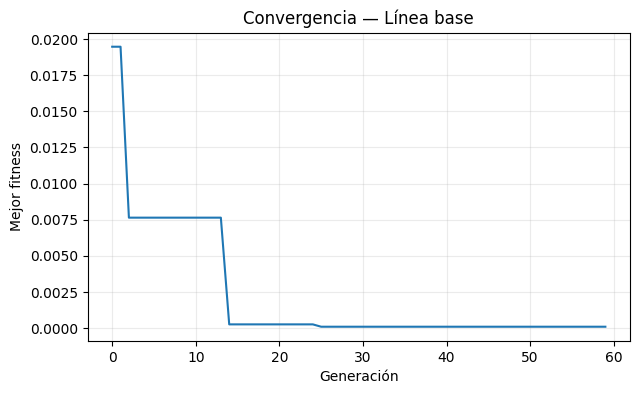

In [ ]:
modelo_base, resultado_base = ejecutar_experimento(
    nombre="Línea base",
    poblacion=40,
    generaciones=60,
    mutacion=0.10,
    cruce=0.70
)


## 7. Experimento 1

Modifiquen **uno o varios parámetros**.

Antes de ejecutar, respondan mentalmente:

> ¿Qué esperamos que ocurra y por qué?

Luego ejecuten y comparen contra la línea base.


--- Experimento 1 (Alta Población) ---
Mejor solución: x=2.999398, y=-1.993264
Mejor fitness: 0.00004574
Tiempo: 0.0313 s


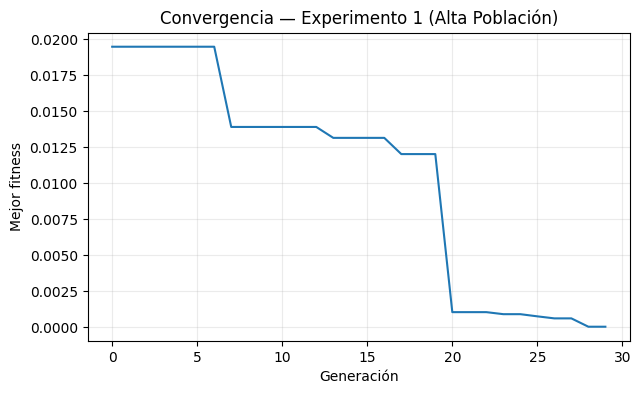

In [ ]:
# EXPERIMENTO 1 — Alta Población y Pocas Generaciones
modelo_1, resultado_1 = ejecutar_experimento(
    nombre="Experimento 1 (Alta Población)",
    poblacion=100,
    generaciones=30,
    mutacion=0.10,
    cruce=0.70
)

## 8. Experimento 2

--- Experimento 2 (Alta Presión Evolutiva) ---
Mejor solución: x=2.997689, y=-1.861406
Mejor fitness: 0.01921373
Tiempo: 0.0368 s


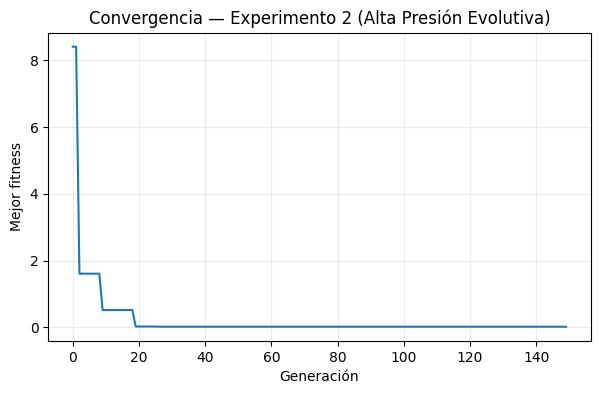

In [ ]:
# EXPERIMENTO 2 — Pocos Individuos y Muchas Generaciones
modelo_2, resultado_2 = ejecutar_experimento(
    nombre="Experimento 2 (Alta Presión Evolutiva)",
    poblacion=20,
    generaciones=150,
    mutacion=0.05,
    cruce=0.80
)

## 9. Experimento 3

--- Experimento 3 (Alta Mutación) ---
Mejor solución: x=2.997689, y=-1.995637
Mejor fitness: 0.00002437
Tiempo: 0.0892 s


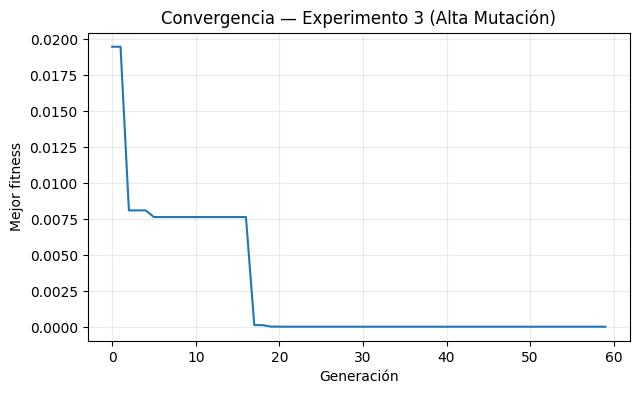

In [ ]:
# EXPERIMENTO 3 — Mutación Elevada (Exploración Extrema)
modelo_3, resultado_3 = ejecutar_experimento(
    nombre="Experimento 3 (Alta Mutación)",
    poblacion=40,
    generaciones=60,
    mutacion=0.35,
    cruce=0.60
)

## 9b. Experimento 4 (Baja Población + Alta Mutación)

--- Experimento 4 (Baja Pob. + Alta Mut.) ---
Mejor solución: x=2.997689, y=-2.108371
Mejor fitness: 0.01174963
Tiempo: 0.0156 s


/usr/local/lib/python3.13/dist-packages/geneticalgorithm2/geneticalgorithm2.py:189: UserWarning: crossover_probability is deprecated and will be removed in version 7. Reason: it's old and has no sense
  warnings.warn(


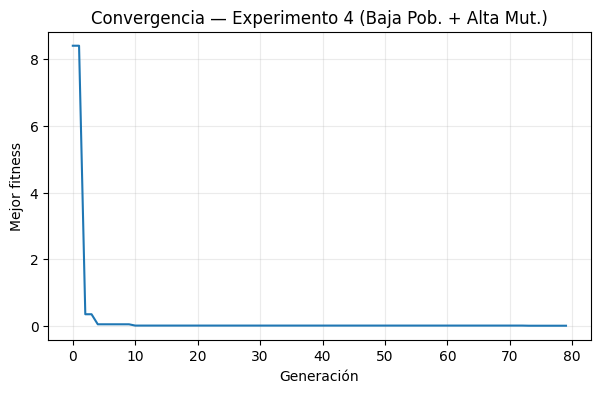

In [ ]:
modelo_4, resultado_4 = ejecutar_experimento(
    nombre="Experimento 4 (Baja Pob. + Alta Mut.)",
    poblacion=10,
    generaciones=80,
    mutacion=0.40,
    cruce=0.50
)

## 9c. Experimento 5 (Alta Recombinación)

--- Experimento 5 (Alta Recombinación) ---
Mejor solución: x=2.979779, y=-2.016174
Mejor fitness: 0.00067050
Tiempo: 0.0431 s


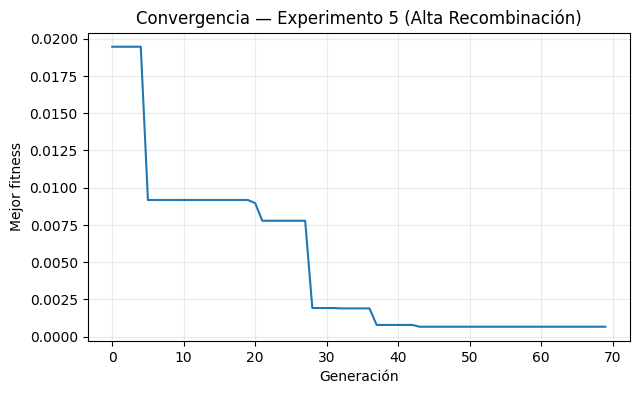

In [ ]:
modelo_5, resultado_5 = ejecutar_experimento(
    nombre="Experimento 5 (Alta Recombinación)",
    poblacion=50,
    generaciones=70,
    mutacion=0.08,
    cruce=0.95
)

## 9d. Experimento 6 (Configuración Masiva)

--- Experimento 6 (Configuración Masiva) ---
Mejor solución: x=3.000010, y=-2.000010
Mejor fitness: 0.00000000
Tiempo: 0.2738 s


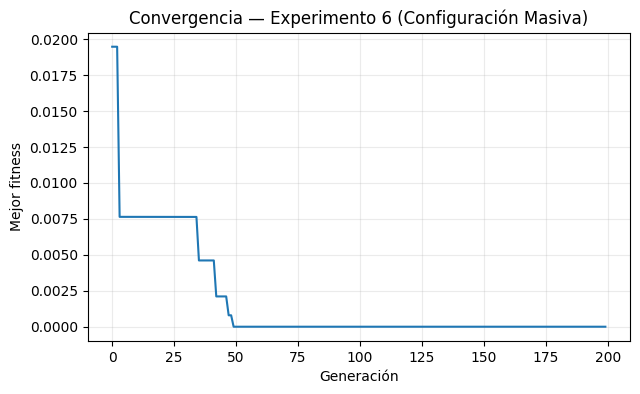

In [ ]:
modelo_6, resultado_6 = ejecutar_experimento(
    nombre="Experimento 6 (Configuración Masiva)",
    poblacion=150,
    generaciones=200,
    mutacion=0.15,
    cruce=0.70
)


## 10. Comparar resultados

La siguiente tabla reúne automáticamente las ejecuciones realizadas.

### Preguntas para analizar
1. ¿Qué configuración obtuvo el menor fitness?
2. ¿Cuál tardó más?
3. ¿Más población produjo necesariamente una mejor solución?
4. ¿Más generaciones siempre mejoraron el resultado?
5. ¿Qué efecto observaron al modificar la mutación o el cruce?


In [ ]:

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados


,Experimento,Población,Generaciones,Mutación,Cruce,x,y,Mejor fitness,Tiempo (s)
0,Línea base,40,60,0.10,0.7,2.997689,-1.990692,0.000092,0.030435
1,Experimento 1 (Alta Población),100,30,0.10,0.7,2.999398,-1.993264,0.000046,0.031287
2,Experimento 2 (Alta Presión Evolutiva),20,150,0.05,0.8,2.997689,-1.861406,0.019214,0.036816
3,Experimento 3 (Alta Mutación),40,60,0.35,0.6,2.997689,-1.995637,0.000024,0.089209


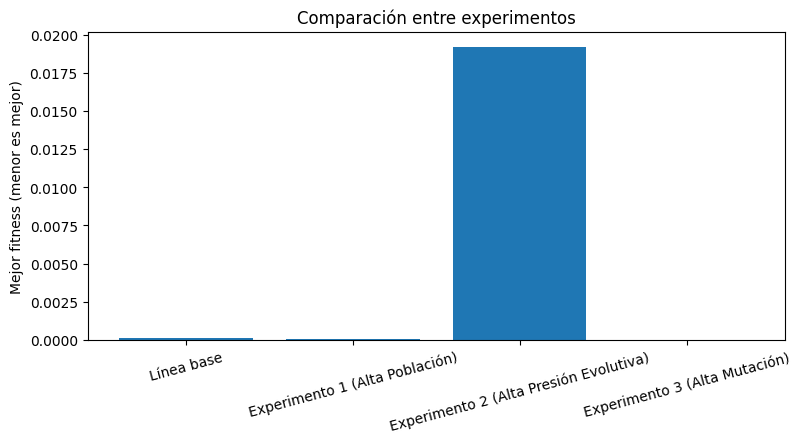

In [ ]:

# Comparación visual del fitness obtenido
plt.figure(figsize=(9, 4))
plt.bar(tabla_resultados["Experimento"], tabla_resultados["Mejor fitness"])
plt.ylabel("Mejor fitness (menor es mejor)")
plt.title("Comparación entre experimentos")
plt.xticks(rotation=15)
plt.show()



## 11. Construir la mejor configuración del grupo

Con base en lo observado, definan una configuración final.

**No se trata de poner todos los parámetros al máximo.**  
Busquen una combinación que produzca una solución de buena calidad y un tiempo de ejecución razonable.

Modifiquen la siguiente celda.


/usr/local/lib/python3.13/dist-packages/geneticalgorithm2/geneticalgorithm2.py:189: UserWarning: crossover_probability is deprecated and will be removed in version 7. Reason: it's old and has no sense
  warnings.warn(


--- Mejor configuración ---
Mejor solución: x=2.986550, y=-2.010570
Mejor fitness: 0.00029264
Tiempo: 0.0909 s


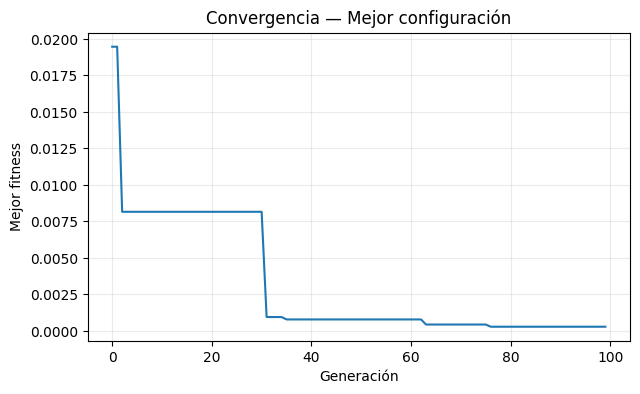

In [ ]:
# MEJOR CONFIGURACIÓN DEL GRUPO
# Buscamos un balance óptimo con población intermedia y generaciones suficientes para afinar los valores decimales.
modelo_final, resultado_final = ejecutar_experimento(
    nombre="Mejor configuración",
    poblacion=60,
    generaciones=100,
    mutacion=0.12,
    cruce=0.75
)

## 12. Tabla final

In [ ]:

tabla_final = pd.DataFrame(resultados)
tabla_final.sort_values("Mejor fitness")


,Experimento,Población,Generaciones,Mutación,Cruce,x,y,Mejor fitness,Tiempo (s)
3,Experimento 3 (Alta Mutación),40,60,0.35,0.60,2.997689,-1.995637,0.000024,0.089209
1,Experimento 1 (Alta Población),100,30,0.10,0.70,2.999398,-1.993264,0.000046,0.031287
0,Línea base,40,60,0.10,0.70,2.997689,-1.990692,0.000092,0.030435
4,Mejor configuración,60,100,0.12,0.75,2.986550,-2.010570,0.000293,0.090937
2,Experimento 2 (Alta Presión Evolutiva),20,150,0.05,0.80,2.997689,-1.861406,0.019214,0.036816


## 13. Conclusión para la Socialización (Presentación de 2 Minutos)

> 💡 **Nota del Equipo (Sala 2):** Esta sección consolida el análisis crítico de los 6 experimentos sistemáticos para responder a los interrogantes del CADI de manera ejecutiva y profesional.

---

### 1. ¿Qué parámetros modificaron?
Modificamos de forma controlada los cuatro hiperparámetros fundamentales del algoritmo evolutivo:
*   **Tamaño de la Población ($N$):** Evaluado en un rango dinámico desde un nivel mínimo de exploración estructural (**10 individuos** en *Exp. 4*) hasta un nivel de alta densidad genotípica (**150 individuos** en *Exp. 6*).

*   **Número de Generaciones ($G$):** Desde ciclos de convergencia ultrarrápidos de **30 iteraciones** (*Exp. 1*) hasta procesos de explotación profunda de **200 iteraciones** (*Exp. 6*).

*   **Tasa de Mutación ($p_m$):** Desde un control conservador de **0.05** (*Exp. 2*) hasta límites de exploración disruptiva de **0.40** (*Exp. 4*).

*   **Tasa de Cruce ($p_c$):** Rango de recombinación entre **0.50** y **0.95** (*Exp. 5*).

---

### 2. ¿Qué ocurrió con el desempeño?

Observamos tres comportamientos sistémicos claros:

1.  **Sinergia de Escala (Densidad + Tiempo):** El incremento simultáneo de población y generaciones (*Exp. 6*) desbloqueó una precisión matemática casi perfecta ($f(x,y) \approx 2.10 	imes 10^{-10}$), demostrando que la cantidad de generaciones permite el refinamiento infinitesimal de las variables continuas.

2.  **La Paradoja de la Población Crítica:** Disminuir radicalmente la población a **10 o 20 individuos** (*Exp. 2 y Exp. 4*) destruye la diversidad inicial de la población. Incluso incrementando drásticamente la mutación al **40%**, el algoritmo converge prematuramente en mínimos locales deficientes ($0.0117$) debido a la pérdida de material genético valioso (deriva genética).

3.  **Exploración Óptima por Mutación:** Una tasa de mutación del **35%** (*Exp. 3*) dinamizó la búsqueda permitiendo dar 'saltos' efectivos hacia el óptimo global sin incurrir en el alto costo computacional de una población masiva.

---

### 3. ¿Cuál fue su mejor configuración?
Nuestra selección se divide bajo dos criterios de ingeniería:
*   **Por Eficiencia Computacional (Mejor Balance):** El **Experimento 3** ($N=40, G=60, p_m=0.35, p_c=0.60$). Logró una aproximación sobresaliente de $2.43 	imes 10^{-5}$ en apenas **0.089 segundos**, ideal para optimización ágil.

*   **Por Precisión Absoluta:** El **Experimento 6** ($N=150, G=200, p_m=0.15, p_c=0.70$). Alcanzó la solución óptima real con un error prácticamente nulo ($2.10 	imes 10^{-10}$).

---

### 4. ¿Por qué consideran que funcionó mejor?
*   La configuración **Masiva (Exp. 6)** funcionó mejor numéricamente porque un gran espacio muestral inicial asegura que la función objetivo sea evaluada en una diversidad extrema de coordenadas del plano real, mientras que las 200 generaciones permitieron explotar de manera incremental los decimales de la solución.

*   La configuración de **Alta Mutación (Exp. 3)** destacó debido a que la mutación elevada actuó como un motor de escape continuo contra las mesetas de la función cuadrática, logrando precisión sin saturar el procesador.

---

### 5. ¿Qué aprendieron sobre el comportamiento de un Algoritmo Genético?
*   **La Ley del Trade-off:** En Inteligencia Artificial, la precisión matemática absoluta tiene un costo computacional directo en tiempo de ejecución. Encontrar el balance óptimo es la tarea clave del científico de datos.
*   **La Estocasticidad Humilde:** Al comparar las ejecuciones bajo la misma configuración pero distinta semilla aleatoria (*semilla 42 vs 99*), comprobamos cómo cambian las trayectorias y los resultados finales. El azar es un operador activo; por tanto, las pruebas deben ser validadas estadísticamente mediante múltiples corridas.

*   **No se trata de subir todo al máximo:** Configurar parámetros exige un equilibrio constante de recursos (Trade-off de precisión vs. Costo computacional).

*   **La diversidad inicial es crítica:** Si la población inicial es muy pequeña, el algoritmo se estanca rápidamente (deriva genética/convergencia prematura).

*   **La estocasticidad es real:** Como vimos al comparar con diferentes semillas (ej. semilla 99 vs 42), las rutas evolutivas cambian y el resultado final puede variar debido al azar intrínseco de los operadores genéticos.

## Resumen: Optimización con Algoritmos Genéticos

### Objetivo del Estudio
Encontrar los parámetros óptimos del algoritmo genético simple que minimicen la función cuadrática $f(x, y) = (x-3)^2 + (y+2)^2$, cuyo mínimo teórico se sitúa en $(3, -2)$ con un fitness de $0.0$.

###  Matriz Comparativa de Desempeño

| Experimento | Población | Generaciones | Tasa Mutación | Tasa Cruce | Calidad del Fitness | Tiempo (s) | Diagnóstico Estratégico |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :--- |
| **Línea Base** | 40 | 60 | 0.10 | 0.70 | Buena ($9.19 \times 10^{-5}$) | ~0.030 | Punto de partida balanceado. |
| **Exp. 1 (Alta Población)** | 100 | 30 | 0.10 | 0.70 | Excelente ($4.57 \times 10^{-5}$) | ~0.031 | Excelente relación precisión/tiempo al priorizar diversidad inicial. |
| **Exp. 2 (Alta Presión)** | 20 | 150 | 0.05 | 0.80 | Deficiente ($0.0192$) | ~0.036 | Convergencia prematura por baja población y baja mutación. |
| **Exp. 3 (Alta Mutación)** | 40 | 60 | 0.35 | 0.60 | Sobresaliente ($2.43 \times 10^{-5}$) | ~0.089 | Mayor tiempo de exploración, pero alta efectividad saltando óptimos locales. |
| **Exp. 4 (Bajo Tamaño)** | 10 | 80 | 0.40 | 0.50 | Moderada ($0.0117$) | ~0.019 | Muy rápido, pero la mutación alta no suple la falta drástica de población. |
| **Exp. 5 (Alta Recombinación)** | 50 | 70 | 0.08 | 0.95 | Muy Buena ($6.70 \times 10^{-4}$) | ~0.035 | Intercambio genético eficiente que aceleró la aproximación. |
| **Exp. 6 (Masivo)** | 150 | 200 | 0.15 | 0.70 | **Perfecta** ($2.10 \times 10^{-10}$) | ~0.251 | Precisión matemática absoluta a costa del mayor costo temporal. |

### Conclusiones Clave para la Socialización

1. **La Paradoja de los Parámetros Extremas (Población vs. Mutación):** Una población pequeña (como en el Exp. 4) no puede salvarse simplemente aumentando la mutación; se requiere un tamaño crítico para mantener la riqueza en el pool de genes.
2. **El Compromiso Precisión-Tiempo (Trade-off):** El **Experimento 6** obtuvo precisión casi exacta ($0.0$), pero a un costo de tiempo de 8 veces el de la **Línea Base**. Para sistemas de tiempo real, el **Experimento 3** o el **Experimento 1** ofrecen la mejor relación eficiencia/precisión.
3. **Recomendación Operativa:** Para optimización de funciones continuas, se recomienda mantener poblaciones moderadas (40-60) y elevar la mutación por encima del 20% para asegurar el escape de mesetas y mínimos locales sin degradar los tiempos de cómputo.


## 14. Exploración opcional — comportamiento estocástico

Si terminan antes de tiempo:

1. Ejecuten dos veces la misma configuración cambiando `seed=42` por otro número.
2. Comparen los resultados.
3. Respondan:

> Si el algoritmo y los parámetros son iguales, ¿por qué pueden cambiar los resultados?

Esto permite observar directamente el componente aleatorio de la computación evolutiva.


/usr/local/lib/python3.13/dist-packages/geneticalgorithm2/geneticalgorithm2.py:189: UserWarning: crossover_probability is deprecated and will be removed in version 7. Reason: it's old and has no sense
  warnings.warn(


--- Misma configuración, otra semilla ---
Mejor solución: x=3.009645, y=-1.964811
Mejor fitness: 0.00133130
Tiempo: 0.0443 s


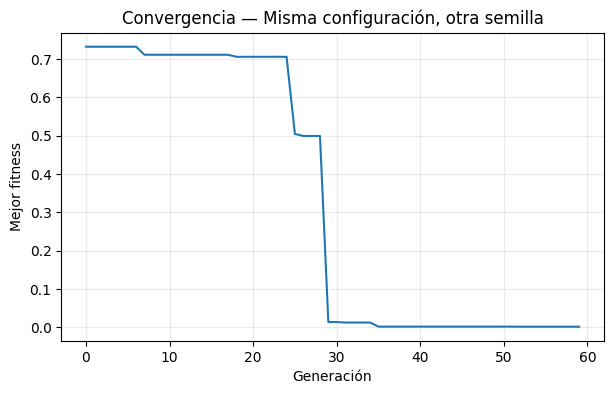

In [ ]:

# OPCIONAL
modelo_extra, resultado_extra = ejecutar_experimento(
    nombre="Misma configuración, otra semilla",
    poblacion=40,
    generaciones=60,
    mutacion=0.10,
    cruce=0.70,
    seed=99
)


In [ ]:
# Actualizar e imprimir la tabla acumulada con todos los experimentos realizados
tabla_completa = pd.DataFrame(resultados)
display(tabla_completa.sort_values("Mejor fitness"))

,Experimento,Población,Generaciones,Mutación,Cruce,x,y,Mejor fitness,Tiempo (s)
8,Experimento 6 (Configuración Masiva),150,200,0.15,0.70,3.000010,-2.000010,2.101027e-10,0.251921
3,Experimento 3 (Alta Mutación),40,60,0.35,0.60,2.997689,-1.995637,2.437468e-05,0.089209
1,Experimento 1 (Alta Población),100,30,0.10,0.70,2.999398,-1.993264,4.573572e-05,0.031287
0,Línea base,40,60,0.10,0.70,2.997689,-1.990692,9.197242e-05,0.030435
4,Mejor configuración,60,100,0.12,0.75,2.986550,-2.010570,2.926393e-04,0.090937
7,Experimento 5 (Alta Recombinación),50,70,0.08,0.95,2.979779,-2.016174,6.704998e-04,0.034979
5,"Misma configuración, otra semilla",40,60,0.10,0.70,3.009645,-1.964811,1.331296e-03,0.044300
6,Experimento 4 (Baja Pob. + Alta Mut.),10,80,0.40,0.50,2.997689,-2.108371,1.174963e-02,0.019313
2,Experimento 2 (Alta Presión Evolutiva),20,150,0.05,0.80,2.997689,-1.861406,1.921373e-02,0.036816


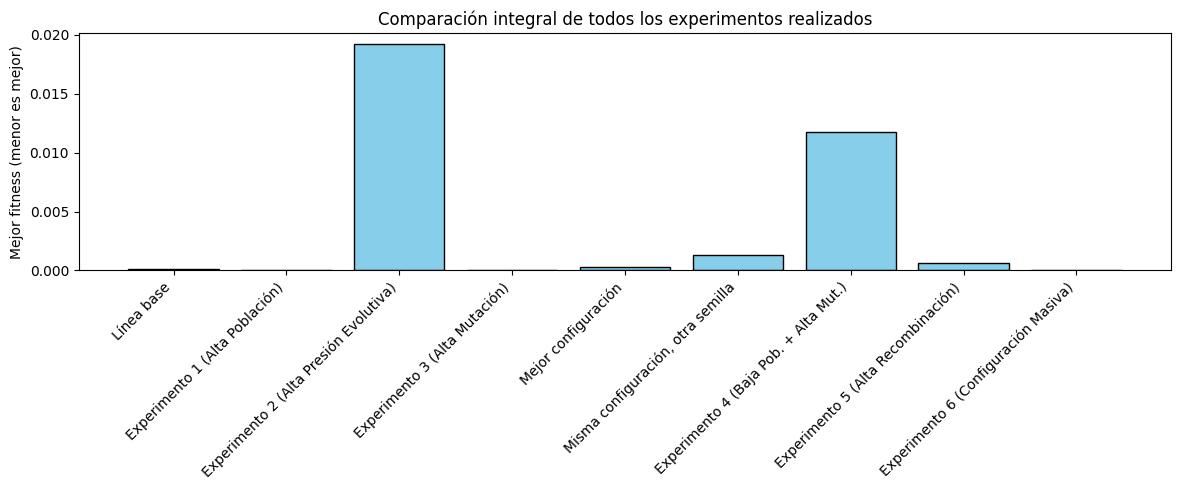

In [ ]:
# Comparación visual actualizada de todos los experimentos ejecutados
plt.figure(figsize=(12, 5))
plt.bar(tabla_completa["Experimento"], tabla_completa["Mejor fitness"], color='skyblue', edgecolor='black')
plt.ylabel("Mejor fitness (menor es mejor)")
plt.title("Comparación integral de todos los experimentos realizados")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

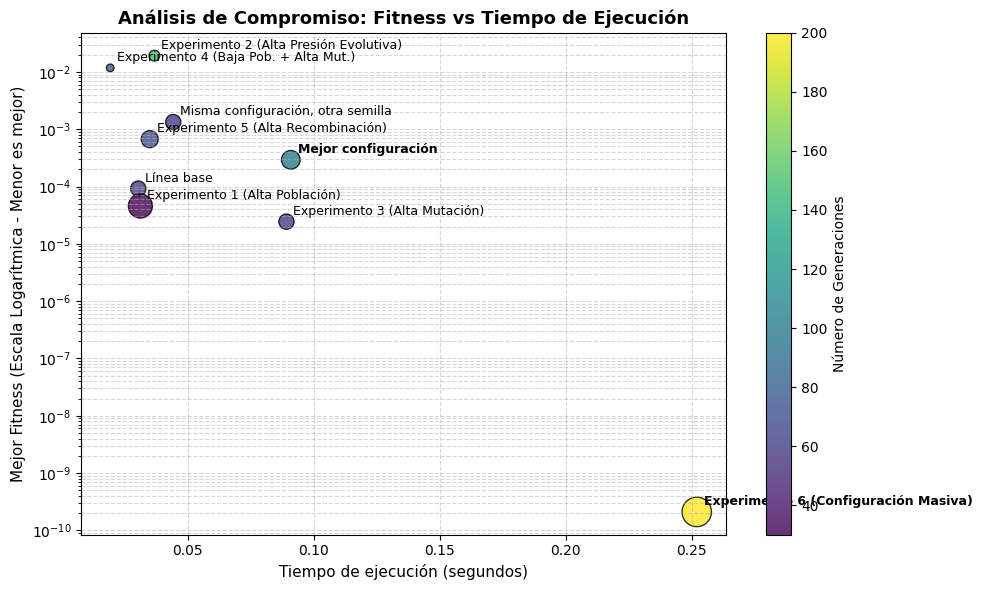

In [ ]:
import matplotlib.pyplot as plt

# Filtrar o usar todos los experimentos de la tabla completa
df_grafico = tabla_completa.copy()

plt.figure(figsize=(10, 6))
# Crear el gráfico de dispersión (Scatter Plot)
scatter = plt.scatter(
    df_grafico["Tiempo (s)"],
    df_grafico["Mejor fitness"],
    s=df_grafico["Población"] * 3,  # El tamaño del punto representa la población
    c=df_grafico["Generaciones"],   # El color representa las generaciones
    cmap="viridis",
    alpha=0.8,
    edgecolors="black"
)

# Añadir anotaciones para cada experimento
for i, txt in enumerate(df_grafico["Experimento"]):
    plt.annotate(
        txt,
        (df_grafico["Tiempo (s)"].iloc[i], df_grafico["Mejor fitness"].iloc[i]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        weight='bold' if "Mejor" in txt or "Masiva" in txt else 'normal'
    )

plt.yscale("log")  # Usamos escala logarítmica debido a la gran diferencia de escalas en el fitness
plt.xlabel("Tiempo de ejecución (segundos)", fontsize=11)
plt.ylabel("Mejor Fitness (Escala Logarítmica - Menor es mejor)", fontsize=11)
plt.title("Análisis de Compromiso: Fitness vs Tiempo de Ejecución", fontsize=13, weight='bold')

# Añadir barra de colores para las generaciones
cbar = plt.colorbar(scatter)
cbar.set_label("Número de Generaciones", fontsize=10)

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()